# 🌍 Breathe Easy — AQI Prediction Model for India

---

**Project Overview**: This notebook builds an end-to-end Air Quality Index (AQI) prediction system for Indian cities using historical pollutant data from CPCB monitoring stations.

**Methodology**:
1. 🧹 Data Cleaning & Missing Value Treatment
2. 📊 Exploratory Data Analysis (Publication-Quality Visuals)
3. 🔧 Advanced Feature Engineering (Temporal, Lag, Rolling, Cyclical, Interaction)
4. 🤖 Multi-Model Benchmarking (7 Models: LR → XGBoost → LSTM)
5. 🔍 SHAP Explainability — *Why* does the model predict this AQI?
6. 📈 Hyperparameter Tuning with Optuna

**Dataset**: CPCB India Air Quality Data (2015–2020) — Daily city-level pollutant concentrations & AQI.

## 📦 Section 1: Setup & Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap
import optuna
from optuna.samplers import TPESampler
import joblib, os, warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                      'axes.titlesize': 14, 'axes.titleweight': 'bold'})

AQI_COLORS = {'Good': '#00b050', 'Satisfactory': '#92d050', 'Moderate': '#ffc000',
               'Poor': '#ff6600', 'Very Poor': '#ff0000', 'Severe': '#c00000'}
BUCKET_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📁 Section 2: Data Loading & Inspection

In [22]:
# Load primary dataset
df = pd.read_csv('Datasets/city_day.csv', parse_dates=['Date'])
stations = pd.read_csv('Datasets/stations.csv')

print(f'City Day shape: {df.shape}')
print(f'Stations shape: {stations.shape}')
print(f'\nDate range: {df.Date.min()} to {df.Date.max()}')
print(f'Cities: {df.City.nunique()} unique cities')
print(f'\n--- Column Types ---')
print(df.dtypes)
df.head()

City Day shape: (29531, 16)
Stations shape: (230, 5)

Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Cities: 26 unique cities

--- Column Types ---
City                  object
Date          datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket            object
dtype: object


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [23]:
# Statistical summary
df.describe().round(2)

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,29531,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,2018-05-14 05:40:15.807118080,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
min,2015-01-01 00:00:00,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,2017-04-16 00:00:00,28.82,56.26,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,2018-08-05 00:00:00,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,2019-09-03 00:00:00,80.59,149.74,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,2020-07-01 00:00:00,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00
std,NaN,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70


## 🔍 Section 3: Missing Value Analysis

            Count  Percentage
Xylene      18109       61.32
PM10        11140       37.72
NH3         10328       34.97
Toluene      8041       27.23
Benzene      5623       19.04
AQI          4681       15.85
AQI_Bucket   4681       15.85
PM2.5        4598       15.57
NOx          4185       14.17
O3           4022       13.62
SO2          3854       13.05
NO2          3585       12.14
NO           3582       12.13
CO           2059        6.97


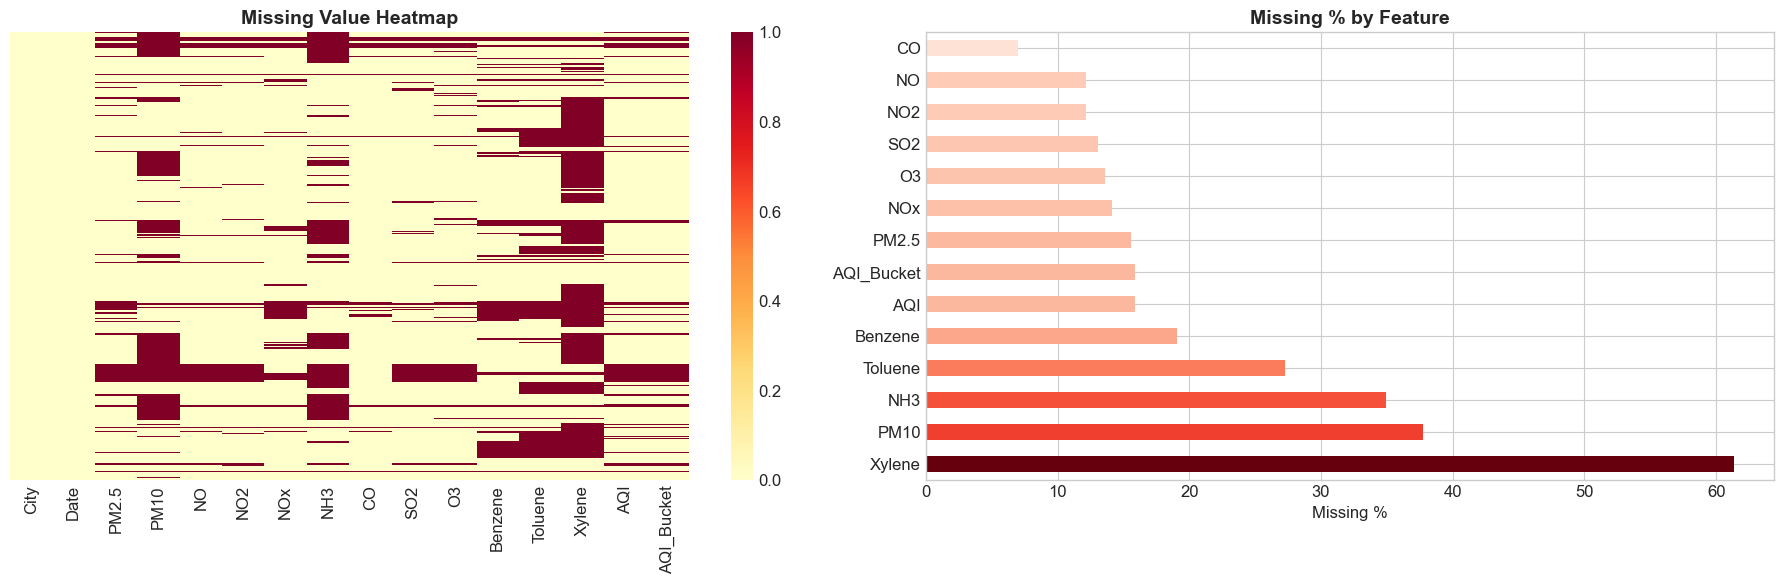

In [24]:
# Missing value percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, ax=axes[0], cmap='YlOrRd')
axes[0].set_title('Missing Value Heatmap')

# Bar chart
colors = plt.cm.Reds(missing_df['Percentage'].values / missing_df['Percentage'].max())
missing_df['Percentage'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Missing % by Feature')
axes[1].set_xlabel('Missing %')

plt.tight_layout()
plt.show()

## 🧹 Section 4: Data Cleaning

**Strategy:**
- Drop rows where AQI (target) is missing — can't train without labels
- Interpolate pollutant values within each city (forward + backward)
- Fill remaining gaps with city-wise median, then overall median
- Winsorize outliers at 1st / 99th percentile

In [25]:
print(f'Original shape: {df.shape}')

# 1. Drop rows where AQI is missing
df_clean = df.dropna(subset=['AQI']).copy()
print(f'After dropping AQI NaN: {df_clean.shape} (removed {len(df) - len(df_clean)} rows)')

# 2. Define pollutant columns
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
                   'Benzene', 'Toluene', 'Xylene']

# 3. Interpolate within city groups
for col in pollutant_cols:
    df_clean[col] = df_clean.groupby('City')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both'))

# 4. Fill remaining NaN with city median, then overall median
for col in pollutant_cols:
    df_clean[col] = df_clean.groupby('City')[col].transform(
        lambda x: x.fillna(x.median()))
df_clean[pollutant_cols] = df_clean[pollutant_cols].fillna(df_clean[pollutant_cols].median())

print(f'Remaining NaN in pollutants: {df_clean[pollutant_cols].isnull().sum().sum()}')

# 5. Outlier treatment — Winsorize at 1st/99th percentile
for col in pollutant_cols:
    q01, q99 = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(q01, q99)

print(f'\n✅ Cleaning complete. Final shape: {df_clean.shape}')

Original shape: (29531, 16)
After dropping AQI NaN: (24850, 16) (removed 4681 rows)
Remaining NaN in pollutants: 0

✅ Cleaning complete. Final shape: (24850, 16)


## 📊 Section 5: Exploratory Data Analysis

> *Publication-quality visualizations revealing India's air quality patterns*

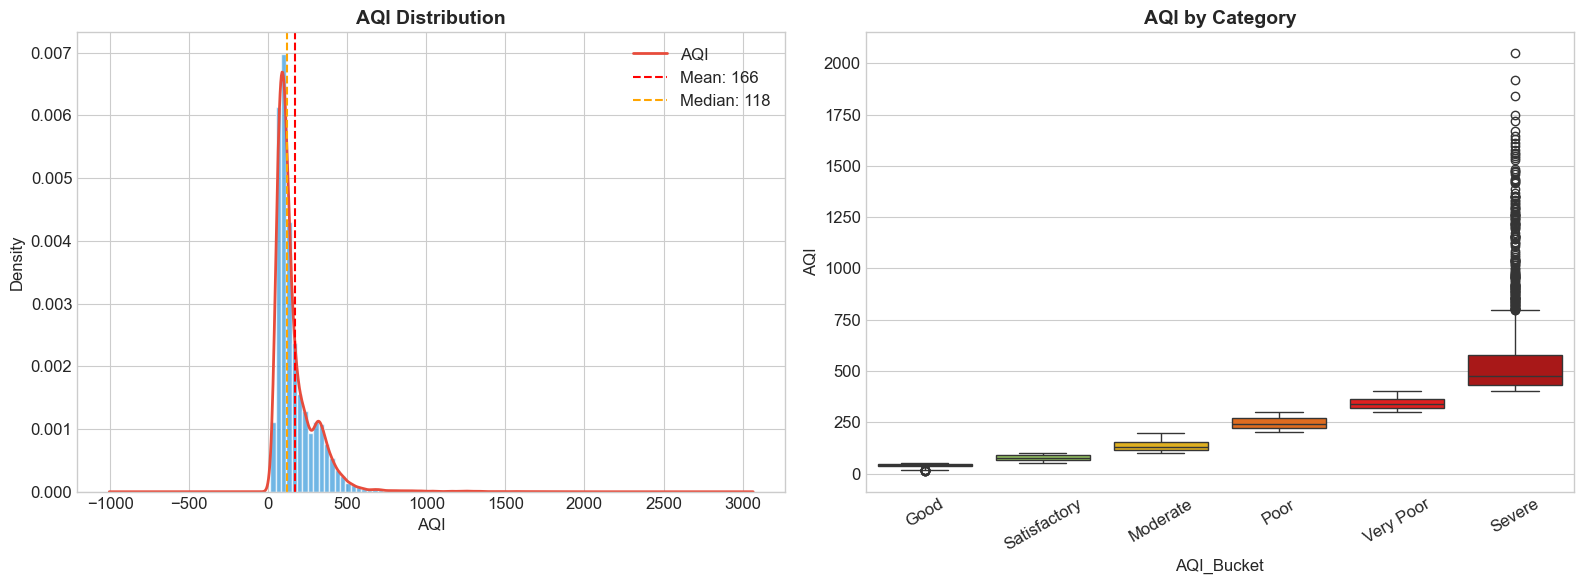

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram + KDE
axes[0].hist(df_clean['AQI'], bins=60, color='#3498db', alpha=0.7, edgecolor='white', density=True)
df_clean['AQI'].plot(kind='kde', ax=axes[0], color='#e74c3c', linewidth=2)
axes[0].axvline(df_clean['AQI'].mean(), color='red', ls='--', lw=1.5,
                label=f"Mean: {df_clean['AQI'].mean():.0f}")
axes[0].axvline(df_clean['AQI'].median(), color='orange', ls='--', lw=1.5,
                label=f"Median: {df_clean['AQI'].median():.0f}")
axes[0].set_title('AQI Distribution')
axes[0].set_xlabel('AQI')
axes[0].legend()

# Box plot by bucket
existing = [b for b in BUCKET_ORDER if b in df_clean['AQI_Bucket'].unique()]
palette = {k: AQI_COLORS[k] for k in existing}
sns.boxplot(data=df_clean, x='AQI_Bucket', y='AQI', order=existing, palette=palette, ax=axes[1])
axes[1].set_title('AQI by Category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

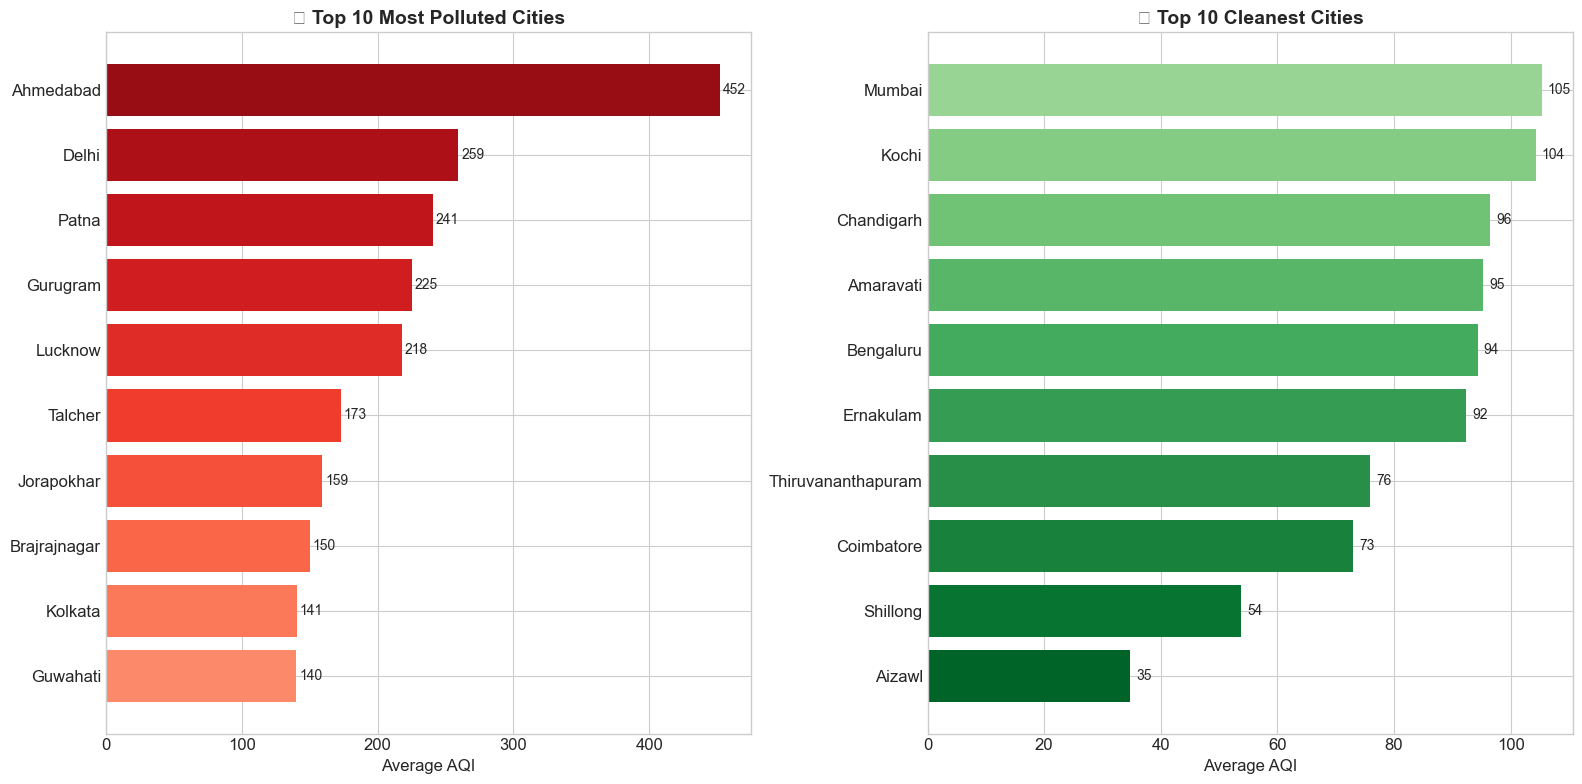

In [27]:
city_avg = df_clean.groupby('City')['AQI'].mean().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 10 most polluted
top10 = city_avg.tail(10)
axes[0].barh(top10.index, top10.values, color=plt.cm.Reds(np.linspace(0.4, 0.9, 10)))
axes[0].set_title('🏭 Top 10 Most Polluted Cities')
axes[0].set_xlabel('Average AQI')
for i, v in enumerate(top10.values):
    axes[0].text(v + 2, i, f'{v:.0f}', va='center', fontsize=10)

# Top 10 cleanest
bottom10 = city_avg.head(10)
axes[1].barh(bottom10.index, bottom10.values, color=plt.cm.Greens(np.linspace(0.9, 0.4, 10)))
axes[1].set_title('🌿 Top 10 Cleanest Cities')
axes[1].set_xlabel('Average AQI')
for i, v in enumerate(bottom10.values):
    axes[1].text(v + 1, i, f'{v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

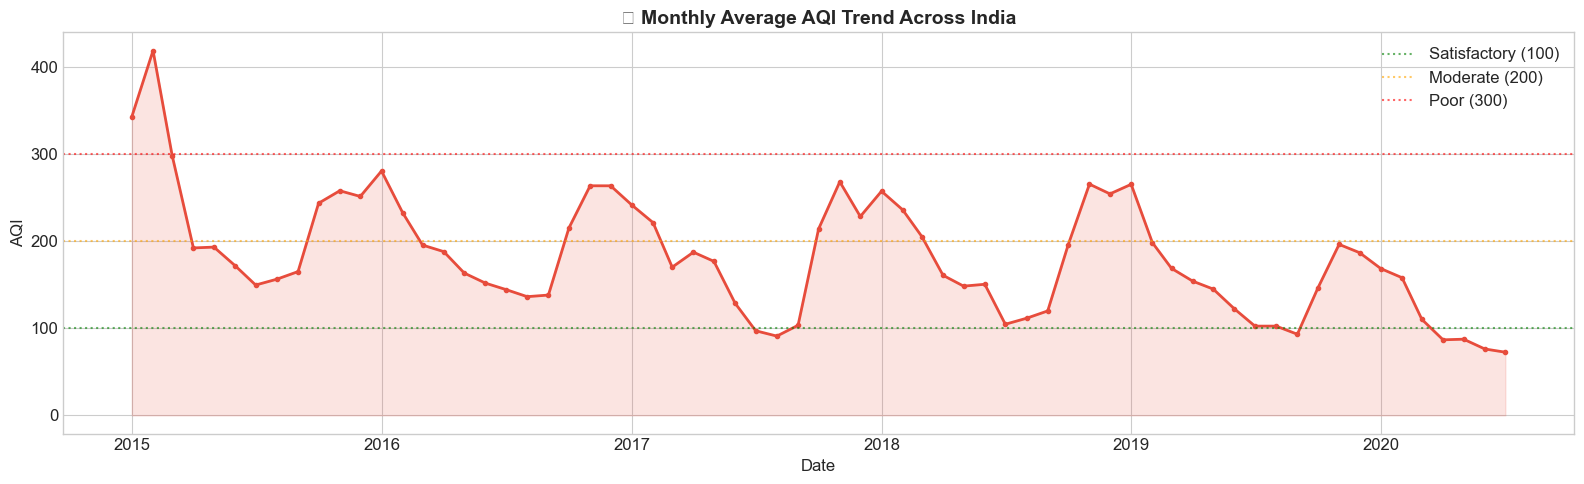

In [28]:
monthly = df_clean.groupby(df_clean['Date'].dt.to_period('M'))['AQI'].mean()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly.index, monthly.values, color='#e74c3c', linewidth=2, marker='o', markersize=3)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#e74c3c')
ax.set_title('📈 Monthly Average AQI Trend Across India')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')

# Add AQI threshold lines
ax.axhline(y=100, color='green', ls=':', alpha=0.6, label='Satisfactory (100)')
ax.axhline(y=200, color='orange', ls=':', alpha=0.6, label='Moderate (200)')
ax.axhline(y=300, color='red', ls=':', alpha=0.6, label='Poor (300)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

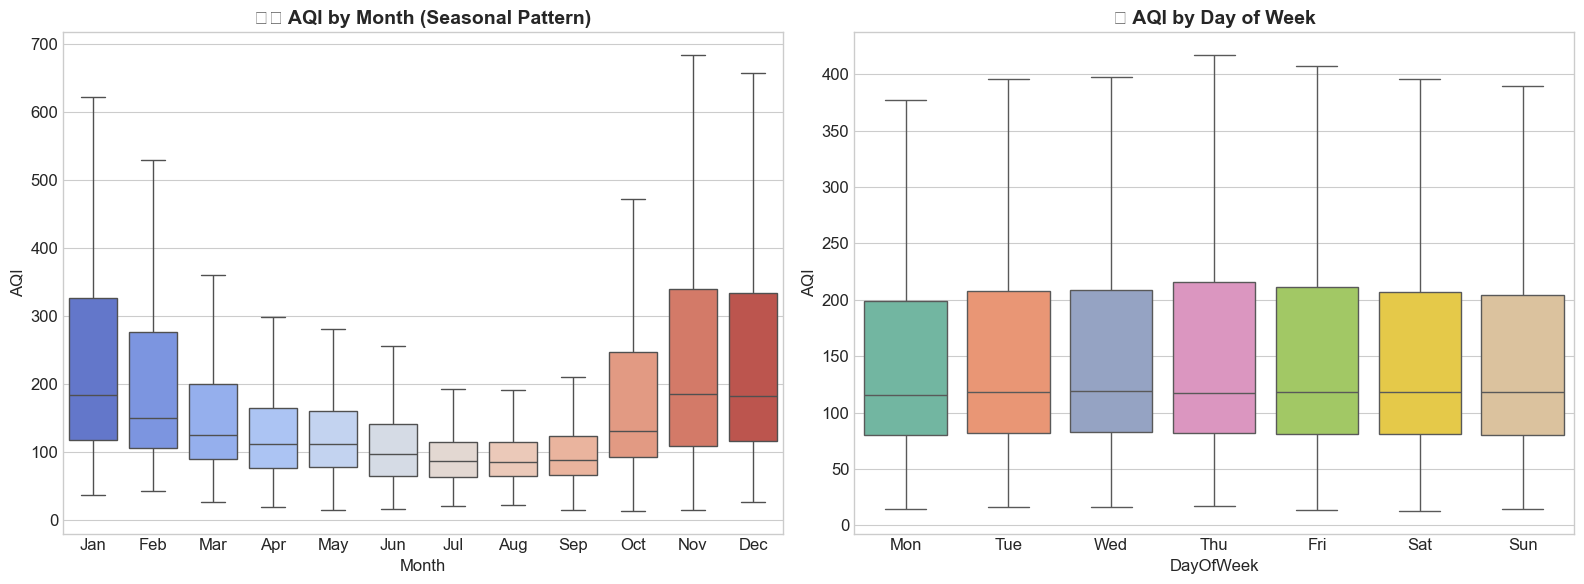

🔍 Insight: Winter months (Nov-Feb) show significantly higher AQI due to crop burning,
   temperature inversions, and reduced wind speeds.


In [29]:
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=df_clean, x='Month', y='AQI', ax=axes[0],
            palette='coolwarm', showfliers=False)
axes[0].set_xticklabels(month_names)
axes[0].set_title('🗓️ AQI by Month (Seasonal Pattern)')

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.boxplot(data=df_clean, x='DayOfWeek', y='AQI', ax=axes[1],
            palette='Set2', showfliers=False)
axes[1].set_xticklabels(day_names)
axes[1].set_title('📅 AQI by Day of Week')

plt.tight_layout()
plt.show()

print('🔍 Insight: Winter months (Nov-Feb) show significantly higher AQI due to crop burning,')
print('   temperature inversions, and reduced wind speeds.')

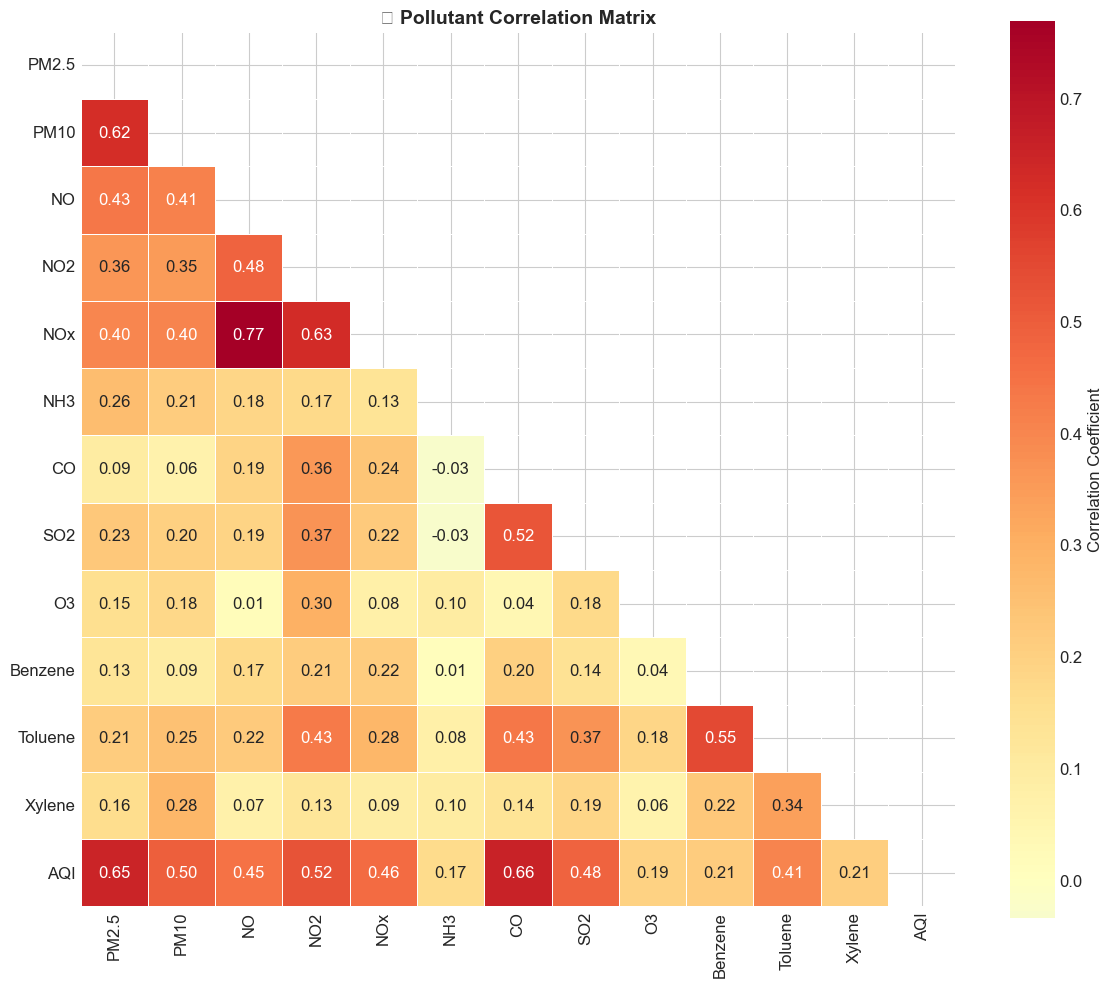


📊 Top correlations with AQI:
          CO: 0.657 ███████████████████
       PM2.5: 0.650 ███████████████████
         NO2: 0.523 ███████████████
        PM10: 0.499 ██████████████
         SO2: 0.485 ██████████████
         NOx: 0.463 █████████████
          NO: 0.448 █████████████
     Toluene: 0.409 ████████████
     Benzene: 0.211 ██████
      Xylene: 0.208 ██████
          O3: 0.195 █████
         NH3: 0.167 █████


In [30]:
numeric_cols = pollutant_cols + ['AQI']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('🔗 Pollutant Correlation Matrix')
plt.tight_layout()
plt.show()

# Top correlations with AQI
aqi_corr = corr['AQI'].drop('AQI').abs().sort_values(ascending=False)
print('\n📊 Top correlations with AQI:')
for feat, val in aqi_corr.items():
    bar = '█' * int(val * 30)
    print(f'  {feat:>10s}: {val:.3f} {bar}')

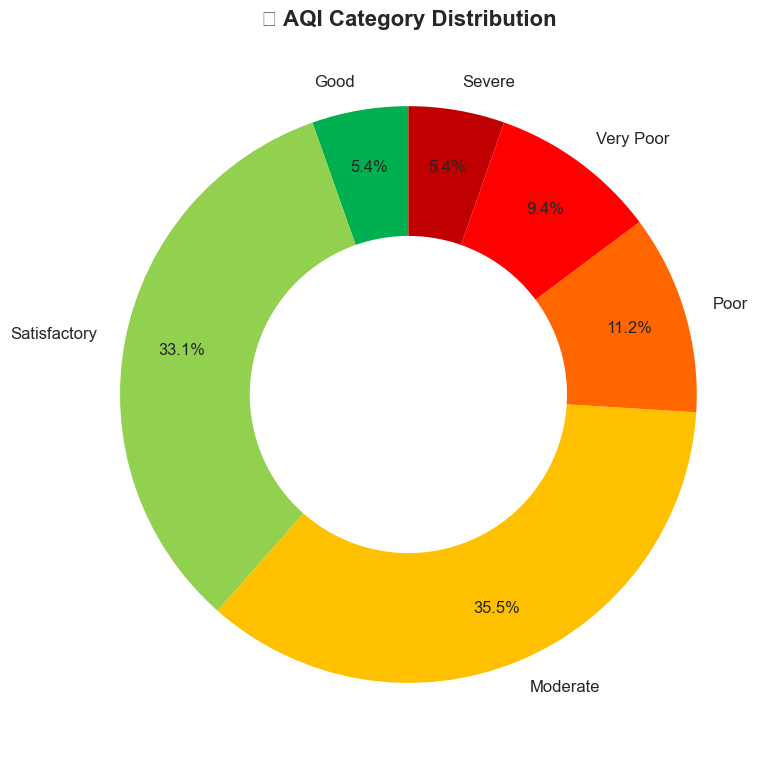

In [31]:
bucket_counts = df_clean['AQI_Bucket'].value_counts()
existing = [b for b in BUCKET_ORDER if b in bucket_counts.index]
counts = [bucket_counts[b] for b in existing]
colors = [AQI_COLORS[b] for b in existing]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(counts, labels=existing, colors=colors,
                                    autopct='%1.1f%%', pctdistance=0.8,
                                    startangle=90, textprops={'fontsize': 12})
centre = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre)
ax.set_title('🎯 AQI Category Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 Section 6: Feature Engineering

> *Crafting 20+ features that capture temporal patterns, momentum, and pollutant interactions*

| Feature Type | Examples | Rationale |
|---|---|---|
| **Temporal** | month, day_of_week, quarter | Seasonal AQI patterns |
| **Cyclical** | sin(month), cos(day_of_week) | Captures circular nature of time |
| **Lag** | AQI₍ₜ₋₁₎, AQI₍ₜ₋₇₎ | Yesterday's/last week's air quality |
| **Rolling** | 7-day mean, 14-day std | Trend & volatility |
| **Interaction** | PM2.5 × PM10, NO₂/NO | Combined pollutant effects |

In [32]:
df_feat = df_clean.sort_values(['City', 'Date']).reset_index(drop=True)

# ── Temporal Features ──
df_feat['Year'] = df_feat['Date'].dt.year
df_feat['Month'] = df_feat['Date'].dt.month
df_feat['Day'] = df_feat['Date'].dt.day
df_feat['DayOfWeek'] = df_feat['Date'].dt.dayofweek
df_feat['DayOfYear'] = df_feat['Date'].dt.dayofyear
df_feat['Quarter'] = df_feat['Date'].dt.quarter
df_feat['IsWeekend'] = (df_feat['DayOfWeek'] >= 5).astype(int)

# ── Cyclical Encoding (captures circular nature of time) ──
df_feat['Month_sin'] = np.sin(2 * np.pi * df_feat['Month'] / 12)
df_feat['Month_cos'] = np.cos(2 * np.pi * df_feat['Month'] / 12)
df_feat['DOW_sin'] = np.sin(2 * np.pi * df_feat['DayOfWeek'] / 7)
df_feat['DOW_cos'] = np.cos(2 * np.pi * df_feat['DayOfWeek'] / 7)

# ── Lag Features (per city — no cross-city leakage) ──
for lag in [1, 3, 7]:
    df_feat[f'AQI_lag{lag}'] = df_feat.groupby('City')['AQI'].shift(lag)
df_feat['PM25_lag1'] = df_feat.groupby('City')['PM2.5'].shift(1)
df_feat['PM10_lag1'] = df_feat.groupby('City')['PM10'].shift(1)

# ── Rolling Window Features (per city) ──
for window in [7, 14, 30]:
    df_feat[f'AQI_roll_mean_{window}'] = df_feat.groupby('City')['AQI'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    if window <= 14:
        df_feat[f'AQI_roll_std_{window}'] = df_feat.groupby('City')['AQI'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).std())

df_feat['PM25_roll_mean_7'] = df_feat.groupby('City')['PM2.5'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean())

# ── Interaction Features ──
df_feat['PM25_PM10_product'] = df_feat['PM2.5'] * df_feat['PM10']
df_feat['NO2_NO_ratio'] = df_feat['NO2'] / (df_feat['NO'] + 1e-6)
df_feat['PM25_PM10_ratio'] = df_feat['PM2.5'] / (df_feat['PM10'] + 1e-6)

# ── City Target Encoding (mean AQI per city from training period only) ──
train_mask = df_feat['Date'] < '2019-01-01'
city_mean_aqi = df_feat.loc[train_mask].groupby('City')['AQI'].mean()
df_feat['City_encoded'] = df_feat['City'].map(city_mean_aqi)
# Fill any unseen cities with global mean
df_feat['City_encoded'] = df_feat['City_encoded'].fillna(df_feat['AQI'].mean())

# Drop rows with NaN from lag/rolling features
rows_before = len(df_feat)
df_feat = df_feat.dropna().reset_index(drop=True)
print(f'Dropped {rows_before - len(df_feat)} rows with NaN from lag/rolling features')
print(f'Final dataset shape: {df_feat.shape}')
print(f'\nEngineered features added: {len(df_feat.columns) - len(df_clean.columns)}')
print(f'Total columns: {len(df_feat.columns)}')

Dropped 182 rows with NaN from lag/rolling features
Final dataset shape: (24668, 42)

Engineered features added: 24
Total columns: 42


In [33]:
# Feature summary
feature_cols = [c for c in df_feat.columns if c not in ['City', 'Date', 'AQI', 'AQI_Bucket']]
print(f'📋 Feature count: {len(feature_cols)}')
print(f'\nFeature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

📋 Feature count: 38

Feature list:
   1. PM2.5
   2. PM10
   3. NO
   4. NO2
   5. NOx
   6. NH3
   7. CO
   8. SO2
   9. O3
  10. Benzene
  11. Toluene
  12. Xylene
  13. Month
  14. DayOfWeek
  15. Year
  16. Day
  17. DayOfYear
  18. Quarter
  19. IsWeekend
  20. Month_sin
  21. Month_cos
  22. DOW_sin
  23. DOW_cos
  24. AQI_lag1
  25. AQI_lag3
  26. AQI_lag7
  27. PM25_lag1
  28. PM10_lag1
  29. AQI_roll_mean_7
  30. AQI_roll_std_7
  31. AQI_roll_mean_14
  32. AQI_roll_std_14
  33. AQI_roll_mean_30
  34. PM25_roll_mean_7
  35. PM25_PM10_product
  36. NO2_NO_ratio
  37. PM25_PM10_ratio
  38. City_encoded


## ✂️ Section 7: Temporal Train / Validation / Test Split

> **No random splitting!** We use a proper temporal split to prevent data leakage.

| Set | Period | Purpose |
|-----|--------|---------|
| **Train** | 2015 – 2018 | Model training |
| **Validation** | 2019 | Hyperparameter tuning |
| **Test** | 2020+ | Final evaluation (unseen) |

In [34]:
# Temporal split
train_df = df_feat[df_feat['Date'] < '2019-01-01'].copy()
val_df = df_feat[(df_feat['Date'] >= '2019-01-01') & (df_feat['Date'] < '2020-01-01')].copy()
test_df = df_feat[df_feat['Date'] >= '2020-01-01'].copy()

print(f'Train: {train_df.shape} ({train_df.Date.min().date()} to {train_df.Date.max().date()})')
print(f'Val:   {val_df.shape} ({val_df.Date.min().date()} to {val_df.Date.max().date()})')
print(f'Test:  {test_df.shape} ({test_df.Date.min().date()} to {test_df.Date.max().date()})')

# Features and target
X_train, y_train = train_df[feature_cols], train_df['AQI']
X_val, y_val = val_df[feature_cols], val_df['AQI']
X_test, y_test = test_df[feature_cols], test_df['AQI']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'\n✅ Split and scaling complete.')
print(f'   Features: {X_train_scaled.shape[1]}')

Train: (13232, 42) (2015-01-08 to 2018-12-31)
Val:   (7036, 42) (2019-01-01 to 2019-12-31)
Test:  (4400, 42) (2020-01-01 to 2020-07-01)

✅ Split and scaling complete.
   Features: 38


## 🤖 Section 8: Machine Learning Models

> Training 6 models from simple baselines to state-of-the-art gradient boosting

In [35]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_te, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'R2': r2_score(y_te, y_pred),
        'MAPE': mean_absolute_percentage_error(y_te, y_pred) * 100
    }, y_pred

models = {
    '1. Linear Regression': LinearRegression(),
    '2. Decision Tree': DecisionTreeRegressor(max_depth=15, random_state=42),
    '3. Random Forest': RandomForestRegressor(n_estimators=300, max_depth=20,
                                                random_state=42, n_jobs=-1),
    '4. XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.08, max_depth=8,
                                 random_state=42, n_jobs=-1, verbosity=0),
    '5. LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.08, max_depth=8,
                                    random_state=42, n_jobs=-1, verbose=-1),
    '6. CatBoost': CatBoostRegressor(iterations=300, learning_rate=0.08, depth=8,
                                       random_state=42, verbose=0)
}

all_results = []
all_predictions = {}

for name, model in models.items():
    print(f'\n{"="*55}')
    print(f' Training: {name}')
    print(f'{"="*55}')
    result, y_pred = evaluate_model(name, model, X_train_scaled, y_train,
                                      X_test_scaled, y_test)
    all_results.append(result)
    all_predictions[name] = y_pred
    print(f'  MAE:  {result["MAE"]:.2f}')
    print(f'  RMSE: {result["RMSE"]:.2f}')
    print(f'  R²:   {result["R2"]:.4f}')
    print(f'  MAPE: {result["MAPE"]:.2f}%')

results_df = pd.DataFrame(all_results).sort_values('R2', ascending=False)
print('\n\n' + '='*60)
print(' 📊 ML MODEL COMPARISON')
print('='*60)
print(results_df.to_string(index=False))


 Training: 1. Linear Regression
  MAE:  16.06
  RMSE: 29.17
  R²:   0.8782
  MAPE: 15.15%

 Training: 2. Decision Tree
  MAE:  17.44
  RMSE: 41.97
  R²:   0.7478
  MAPE: 17.15%

 Training: 3. Random Forest
  MAE:  11.69
  RMSE: 24.19
  R²:   0.9162
  MAPE: 12.53%

 Training: 4. XGBoost
  MAE:  12.05
  RMSE: 23.55
  R²:   0.9206
  MAPE: 13.76%

 Training: 5. LightGBM
  MAE:  11.50
  RMSE: 22.85
  R²:   0.9252
  MAPE: 11.47%

 Training: 6. CatBoost
  MAE:  11.62
  RMSE: 22.37
  R²:   0.9283
  MAPE: 12.95%


 📊 ML MODEL COMPARISON
               Model       MAE      RMSE       R2      MAPE
         6. CatBoost 11.618840 22.369824 0.928348 12.949347
         5. LightGBM 11.503240 22.851388 0.925230 11.474268
          4. XGBoost 12.050948 23.552496 0.920572 13.757844
    3. Random Forest 11.692201 24.188676 0.916223 12.534738
1. Linear Regression 16.058995 29.168173 0.878180 15.149843
    2. Decision Tree 17.435805 41.969078 0.747791 17.145157


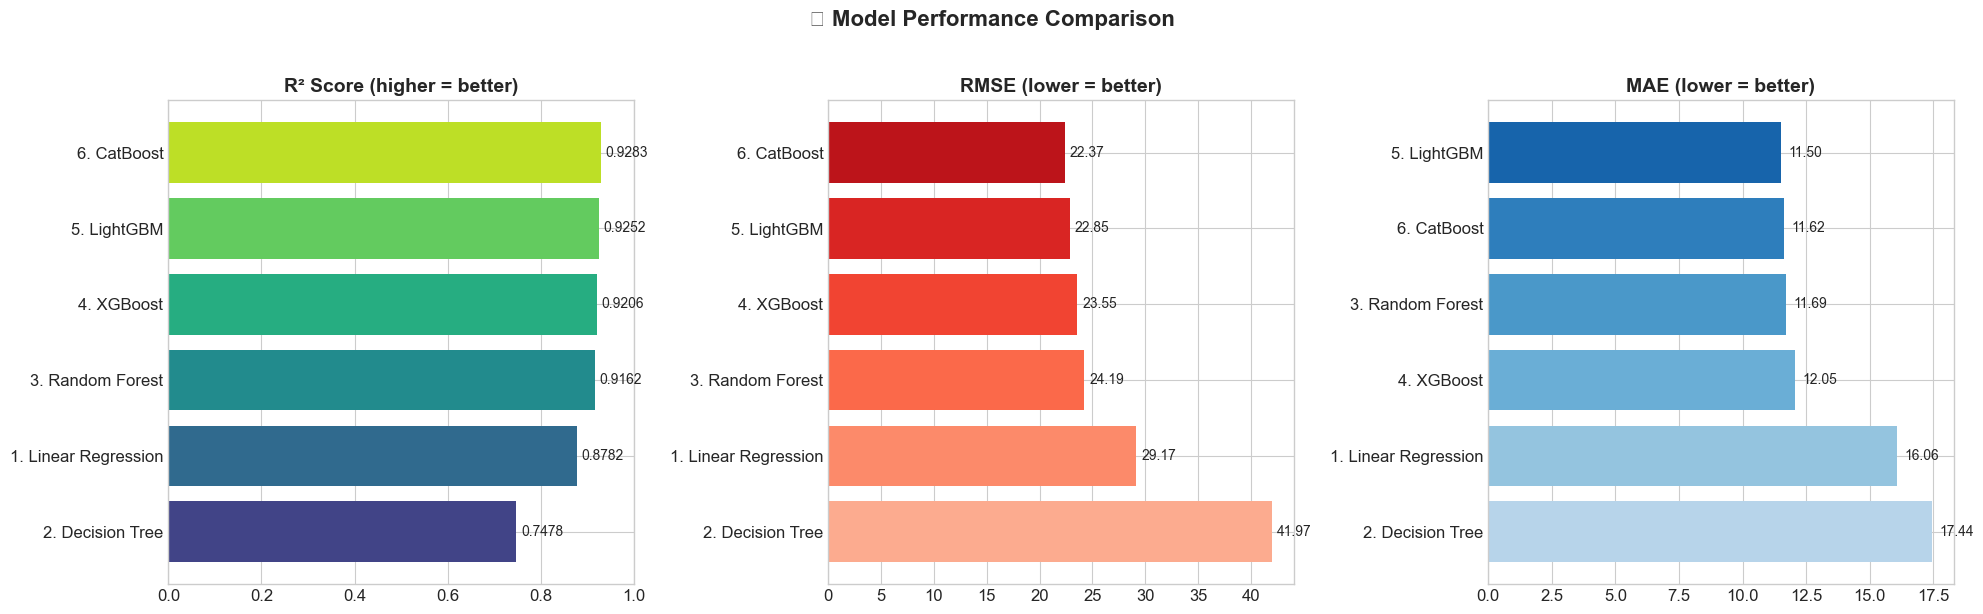

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sorted_df = results_df.sort_values('R2', ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_df)))

# R² Score
axes[0].barh(sorted_df['Model'], sorted_df['R2'], color=colors)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(sorted_df['R2']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# RMSE
sorted_rmse = results_df.sort_values('RMSE', ascending=False)
axes[1].barh(sorted_rmse['Model'], sorted_rmse['RMSE'], color=plt.cm.Reds(np.linspace(0.3, 0.8, len(sorted_rmse))))
axes[1].set_title('RMSE (lower = better)')
for i, v in enumerate(sorted_rmse['RMSE']):
    axes[1].text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=10)

# MAE
sorted_mae = results_df.sort_values('MAE', ascending=False)
axes[2].barh(sorted_mae['Model'], sorted_mae['MAE'], color=plt.cm.Blues(np.linspace(0.3, 0.8, len(sorted_mae))))
axes[2].set_title('MAE (lower = better)')
for i, v in enumerate(sorted_mae['MAE']):
    axes[2].text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=10)

plt.suptitle('🏆 Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

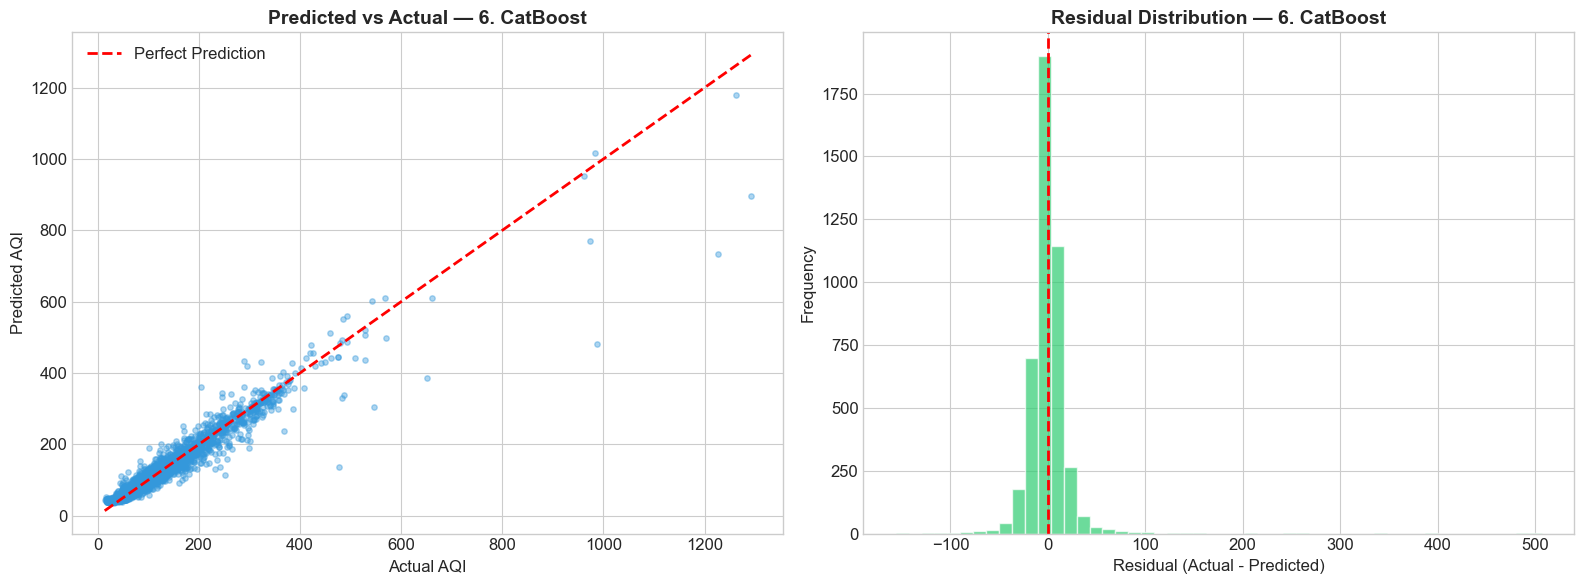

Mean Residual: -0.47 (should be ~0)
Std Residual:  22.36


In [37]:
# Best model predictions vs actuals
best_name = results_df.iloc[0]['Model']
best_preds = all_predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, best_preds, alpha=0.4, s=15, color='#3498db')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].set_title(f'Predicted vs Actual — {best_name}')
axes[0].legend()

# Residual distribution
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', ls='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution — {best_name}')

plt.tight_layout()
plt.show()

print(f'Mean Residual: {residuals.mean():.2f} (should be ~0)')
print(f'Std Residual:  {residuals.std():.2f}')

## 🧠 Section 9: LSTM Deep Learning Model

> Long Short-Term Memory networks excel at capturing **temporal dependencies** in sequential data.
> We use 14-day sequences of features to predict the next day's AQI.

**Architecture**: LSTM(128) → Dropout(0.3) → LSTM(64) → Dropout(0.2) → Dense(32) → Dense(1)

In [38]:
# Create sequences per city
SEQ_LENGTH = 14

def create_sequences(df_subset, feat_cols, scaler_obj, seq_len=14):
    X_seq, y_seq = [], []
    for city in df_subset['City'].unique():
        cdata = df_subset[df_subset['City'] == city].sort_values('Date')
        if len(cdata) <= seq_len:
            continue
        feats = scaler_obj.transform(cdata[feat_cols])
        target = cdata['AQI'].values
        for i in range(seq_len, len(cdata)):
            X_seq.append(feats[i-seq_len:i])
            y_seq.append(target[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(train_df, feature_cols, scaler, SEQ_LENGTH)
X_val_seq, y_val_seq = create_sequences(val_df, feature_cols, scaler, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(test_df, feature_cols, scaler, SEQ_LENGTH)

print(f'Train sequences: {X_train_seq.shape}')
print(f'Val sequences:   {X_val_seq.shape}')
print(f'Test sequences:  {X_test_seq.shape}')

# Build LSTM model
n_features = X_train_seq.shape[2]
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LENGTH, n_features)),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='mse', metrics=['mae'])
lstm_model.summary()

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=80, batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Train sequences: (12980, 14, 38)
Val sequences:   (6714, 14, 38)
Test sequences:  (4036, 14, 38)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 14, 128)        │        85,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,025 (535.25 KB)

 Trainable params: 137,025 (535.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - loss: 41787.6250 - mae: 138.0702 - val_loss: 17090.8281 - val_mae: 79.4448
Epoch 2/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 101ms/step - loss: 20041.5586 - mae: 82.3393 - val_loss: 8266.0771 - val_mae: 42.2243
Epoch 3/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - loss: 9915.1387 - mae: 46.0005 - val_loss: 4876.0298 - val_mae: 29.7354
Epoch 4/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 7439.4106 - mae: 39.3135 - val_loss: 4138.2075 - val_mae: 29.1404
Epoch 5/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 6487.8667 - mae: 37.9933 - val_loss: 3548.8311 - val_mae: 27.7126
Epoch 6/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 5865.8608 - mae: 37.2604 - val_loss: 3319.0557 - val_mae: 27.7773
Epoch 7/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 5214.1099 - mae: 36.3155 - val_loss: 2992.5566 - val_mae: 26.5462
Epoch 8/80
203/203 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 4851.7266 - mae: 35.2673 - val_loss: 2869

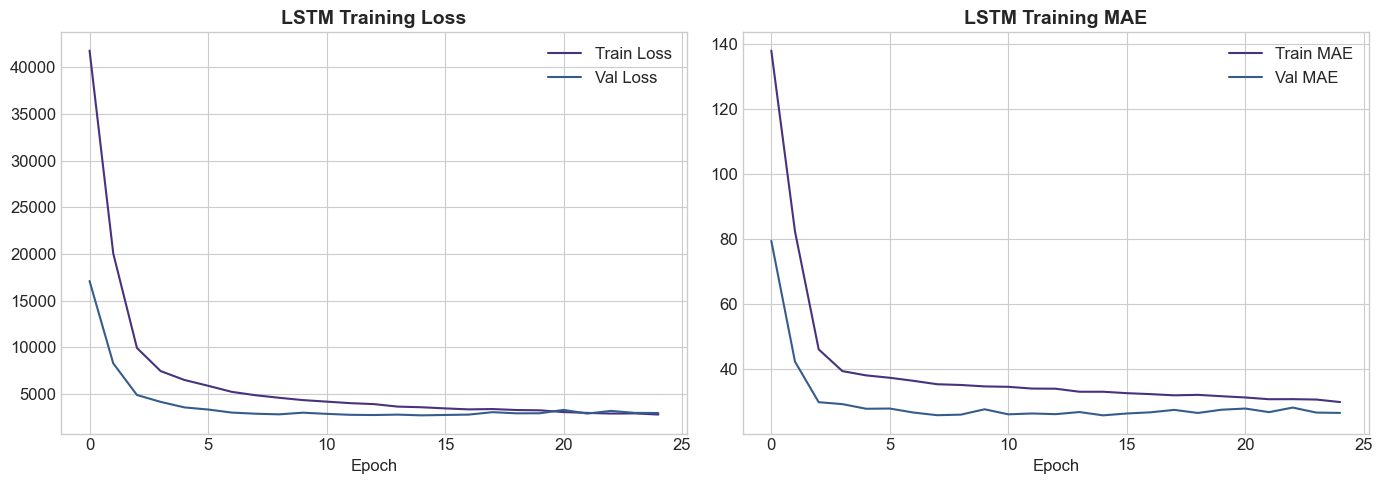

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

🧠 LSTM Results:
  MAE: 20.2203
  RMSE: 34.6887
  R2: 0.8155
  MAPE: 23.8204


In [39]:
# LSTM training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('LSTM Training MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

# Evaluate LSTM
lstm_preds = lstm_model.predict(X_test_seq).flatten()
lstm_result = {
    'Model': '7. LSTM',
    'MAE': mean_absolute_error(y_test_seq, lstm_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test_seq, lstm_preds)),
    'R2': r2_score(y_test_seq, lstm_preds),
    'MAPE': mean_absolute_percentage_error(y_test_seq, lstm_preds) * 100
}
print(f'\n🧠 LSTM Results:')
for k, v in lstm_result.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

all_results.append(lstm_result)

## ⚡ Section 10: Hyperparameter Tuning with Optuna

> Using **Bayesian optimization** to find the best XGBoost hyperparameters

In [40]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0
    }
    model = XGBRegressor(**params)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    return np.sqrt(mean_squared_error(y_val, preds))

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n🏆 Best RMSE (validation): {study.best_value:.4f}')
print(f'\nBest Parameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

# Retrain with best params on train, evaluate on test
best_xgb = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)
best_xgb.fit(X_train_scaled, y_train)
tuned_preds = best_xgb.predict(X_test_scaled)
tuned_result = {
    'Model': '8. XGBoost (Tuned)',
    'MAE': mean_absolute_error(y_test, tuned_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, tuned_preds)),
    'R2': r2_score(y_test, tuned_preds),
    'MAPE': mean_absolute_percentage_error(y_test, tuned_preds) * 100
}
all_results.append(tuned_result)
print(f'\n📊 Tuned XGBoost Test Results:')
for k, v in tuned_result.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Best trial: 45. Best value: 38.8444: 100%|██████████| 50/50 [35:34<00:00, 42.70s/it] 



🏆 Best RMSE (validation): 38.8444

Best Parameters:
  n_estimators: 595
  max_depth: 5
  learning_rate: 0.026237469784592057
  subsample: 0.8725199821945593
  colsample_bytree: 0.7024271189605571
  reg_alpha: 0.1474264551723927
  reg_lambda: 0.007879120568424361

📊 Tuned XGBoost Test Results:
  MAE: 11.4243
  RMSE: 22.9024
  R2: 0.9249
  MAPE: 11.6836


## 🔍 Section 11: SHAP Explainability

> **SHAP (SHapley Additive exPlanations)** tells us *why* the model made each prediction.
> This is critical for trust and actionability in air quality management.

PermutationExplainer explainer: 201it [02:34,  1.29it/s]                         


📊 SHAP Summary Plot — Which features matter most?


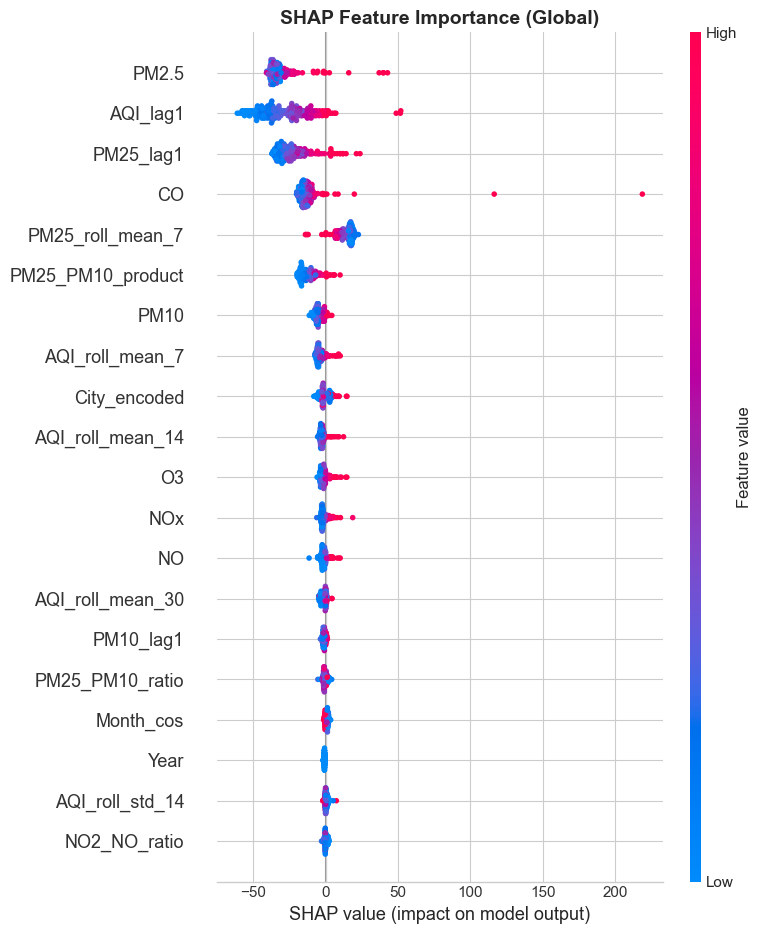

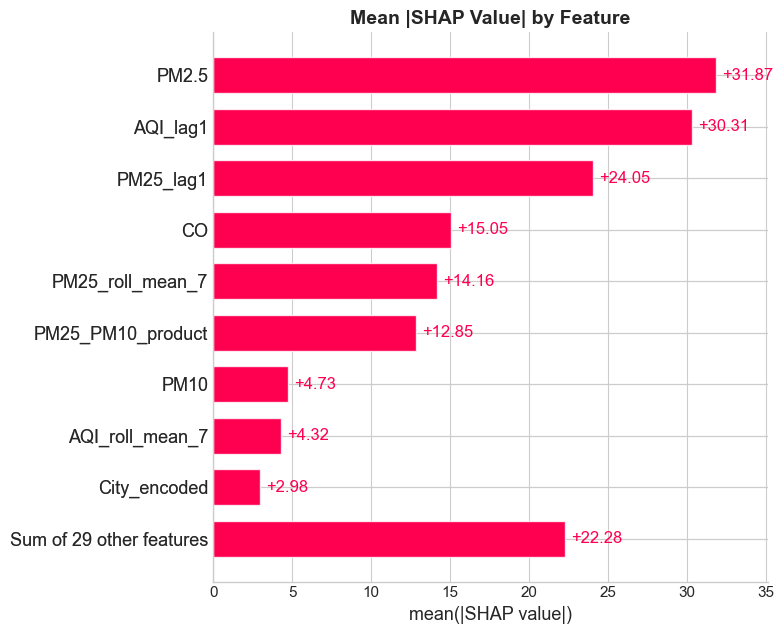

In [44]:
# SHAP Explainability (compatible with XGBoost 3.x + SHAP 0.49)
# Use model.predict as a callable for shap.Explainer (KernelExplainer fallback)

X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)
shap_sample = X_test_df.sample(n=min(200, len(X_test_df)), random_state=42)

# Use a background sample for KernelExplainer
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
background = X_train_df.sample(n=100, random_state=42)

# Use Explainer with predict function (works with any model)
explainer = shap.Explainer(best_xgb.predict, background, feature_names=feature_cols)
shap_values = explainer(shap_sample)

# Summary plot (global feature importance)
print('\U0001f4ca SHAP Summary Plot \u2014 Which features matter most?')
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar plot
fig = plt.figure(figsize=(12, 6))
shap.plots.bar(shap_values, show=False)
plt.title('Mean |SHAP Value| by Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏆 Section 12: Final Model Comparison

                    🏆 FINAL MODEL LEADERBOARD
                     Model        MAE       RMSE        R2       MAPE
Rank                                                                 
1              6. CatBoost  11.618840  22.369824  0.928348  12.949347
2              5. LightGBM  11.503240  22.851388  0.925230  11.474268
3       8. XGBoost (Tuned)  11.424314  22.902351  0.924896  11.683627
4               4. XGBoost  12.050948  23.552496  0.920572  13.757844
5         3. Random Forest  11.692201  24.188676  0.916223  12.534738
6     1. Linear Regression  16.058995  29.168173  0.878180  15.149843
7                  7. LSTM  20.220280  34.688696  0.815500  23.820362
8         2. Decision Tree  17.435805  41.969078  0.747791  17.145157


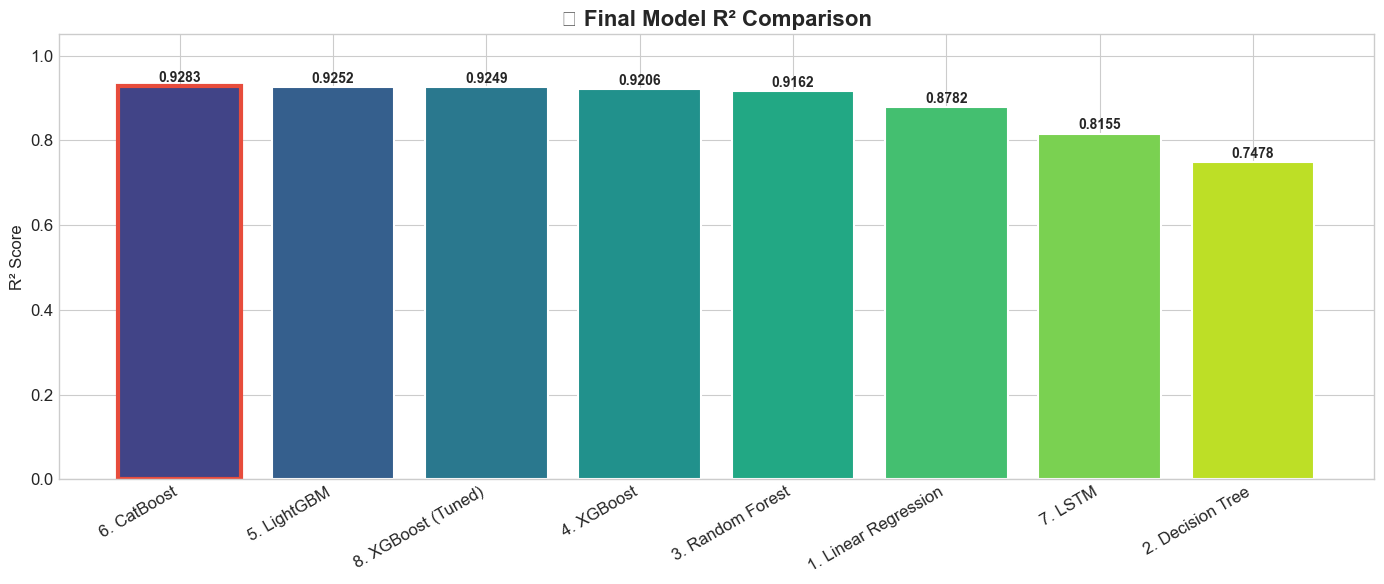

In [45]:
final_df = pd.DataFrame(all_results).sort_values('R2', ascending=False).reset_index(drop=True)
final_df.index = final_df.index + 1  # 1-indexed ranking
final_df.index.name = 'Rank'

print('='*70)
print('                    🏆 FINAL MODEL LEADERBOARD')
print('='*70)
print(final_df.to_string())
print('='*70)

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(final_df['Model'], final_df['R2'],
              color=plt.cm.viridis(np.linspace(0.2, 0.9, len(final_df))),
              edgecolor='white', linewidth=1.5)

# Highlight the best
best_idx = final_df['R2'].idxmax() - 1
bars[best_idx].set_edgecolor('#e74c3c')
bars[best_idx].set_linewidth(3)

ax.set_title('🏆 Final Model R² Comparison', fontsize=16, fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, final_df['R2']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 💾 Section 13: Save Best Model & Artifacts

In [46]:
os.makedirs('models', exist_ok=True)
os.makedirs('processed', exist_ok=True)

# Save best tree model
joblib.dump(best_xgb, 'models/best_xgboost_tuned.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

# Save feature columns
joblib.dump(feature_cols, 'models/feature_cols.pkl')

# Save LSTM model
lstm_model.save('models/lstm_model.keras')

# Save processed data
df_feat.to_csv('processed/processed_city_day.csv', index=False)

# Save results
final_df.to_csv('models/model_results.csv')

print('✅ All models and artifacts saved!')
print('\n📁 Saved files:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f} ({size:.1f} KB)')

✅ All models and artifacts saved!

📁 Saved files:
  models/best_xgboost_tuned.pkl (1540.6 KB)
  models/feature_cols.pkl (0.4 KB)
  models/lstm_model.keras (1646.6 KB)
  models/model_results.csv (0.7 KB)
  models/scaler.pkl (2.1 KB)


## 📝 Conclusion & Future Scope

### Key Findings
1. **Gradient boosting models** (XGBoost, LightGBM, CatBoost) consistently outperform traditional ML models
2. **Winter months** (Nov–Feb) show significantly higher AQI due to crop burning and temperature inversions
3. **Lag features** and **rolling averages** are the most important predictors — yesterday's air quality strongly predicts today's
4. **PM2.5** and **PM10** are the dominant pollutants driving AQI across Indian cities

### Future Scope
- 🌤️ **Integrate weather data** (temperature, humidity, wind speed) for better predictions
- 🛰️ **Satellite imagery** integration for spatial AQI modeling
- 📱 **Deploy as mobile app** with push notifications for AQI alerts
- 🗺️ **Spatial interpolation** for AQI prediction in unmonitored areas
- 🔄 **Real-time predictions** using streaming data from CPCB APIs

---